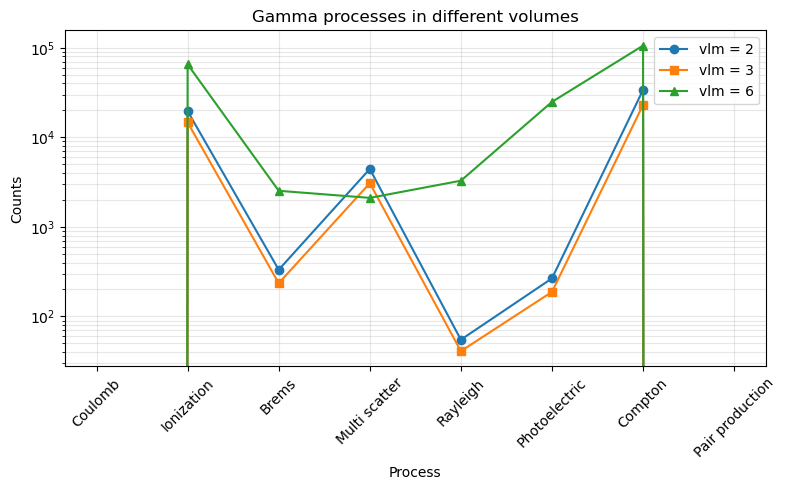

In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "tumor.root"
vlms = [2, 3, 6]

process_dict = {
    2001: "Coulomb",
    2002: "Ionization",
    2003: "Brems",
    2010: "Multi scatter",
    2011: "Rayleigh",
    2012: "Photoelectric",
    2013: "Compton",
    2014: "Pair production",
   
}

process_ids = list(process_dict.keys())

with uproot.open(file_path) as f:
    tree = f["t"]
    pro = np.concatenate(tree["pro"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()

counts = {}
for v in vlms:
    mask = (vlm == v)
    pro_v = pro[mask]
    counts[v] = [np.count_nonzero(pro_v == pid) for pid in process_ids]

x = np.arange(len(process_ids))
width = 0.22

plt.figure(figsize=(8, 5))
plt.plot(x, counts[2], marker="o", label="vlm = 2")
plt.plot(x, counts[3], marker="s", label="vlm = 3")
plt.plot(x, counts[6], marker="^", label="vlm = 6")

plt.xticks(x, [process_dict[pid] for pid in process_ids], rotation=45)
plt.ylabel("Counts")
plt.xlabel("Process")
plt.title("Gamma processes in different volumes")

plt.yscale('log')

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()